In [263]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import (train_test_split, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix)

In [264]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
path=os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df=pd.read_csv(path)

In [265]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [266]:
df.shape

(7043, 21)

In [267]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [268]:
df['TotalCharges']=df['TotalCharges'].replace(' ','')
df['TotalCharges'] = df['TotalCharges'].str.strip()

In [269]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors= 'coerce')

In [270]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [271]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [272]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [273]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [274]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2265.000258
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1400.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Let's See Outliers

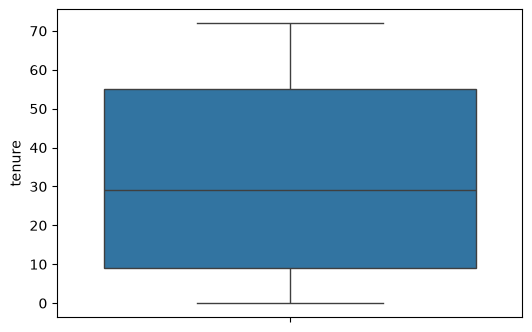

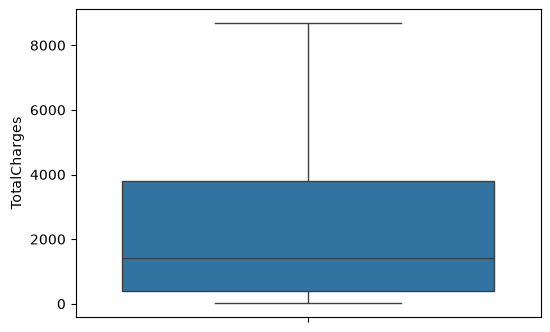

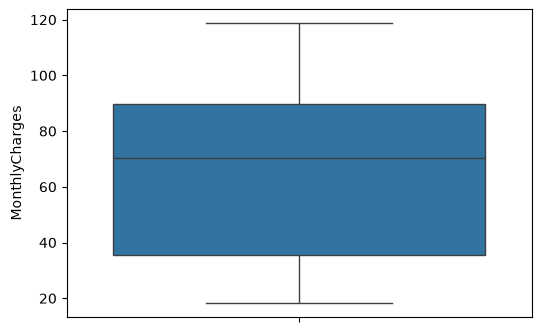

In [275]:
for i in ['tenure', 'TotalCharges', 'MonthlyCharges']:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[i],)
    plt.show()

TotalCharges seems suspicious let's check IQR

In [276]:
Q1 = df["TotalCharges"].quantile(0.25)
Q3 = df["TotalCharges"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalCharges"] < lower) |
    (df["TotalCharges"] > upper)
]

print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(outliers))

Lower bound: -4674.3375
Upper bound: 8863.1625
Number of outliers: 0


The TotalCharges feature contains no outliers according to the 1.5 × IQR rule

EDA

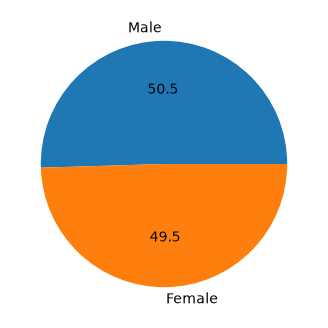

In [277]:
plt.figure(figsize=(6,4))
plt.pie(df['gender'].value_counts(),labels=df['gender'].value_counts().index, autopct='%1.1f')

In [278]:
cat_col=['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

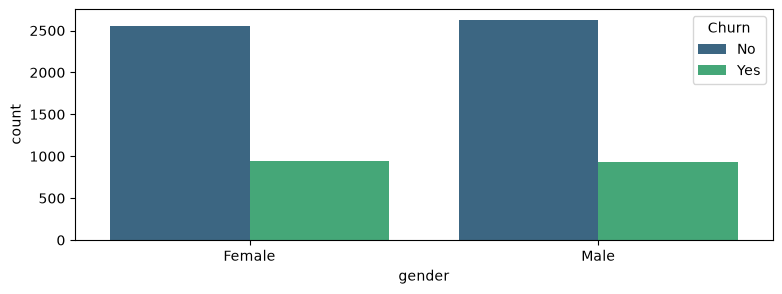

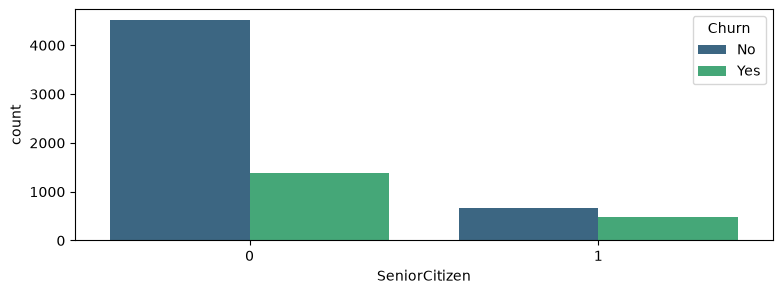

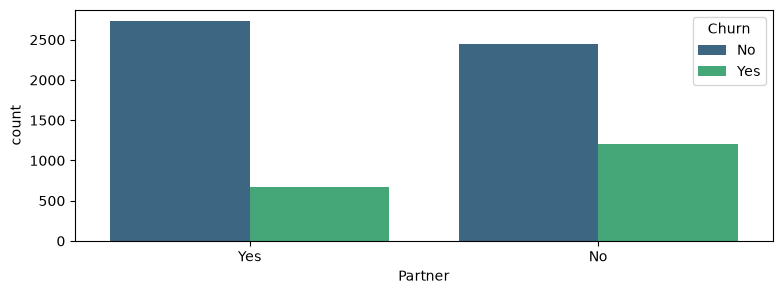

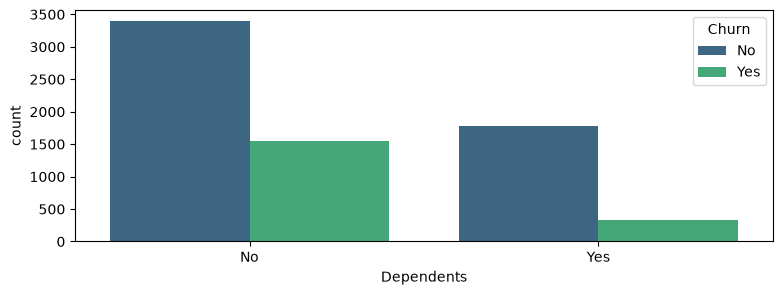

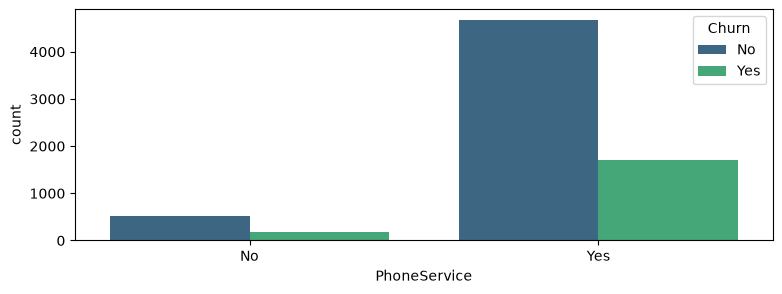

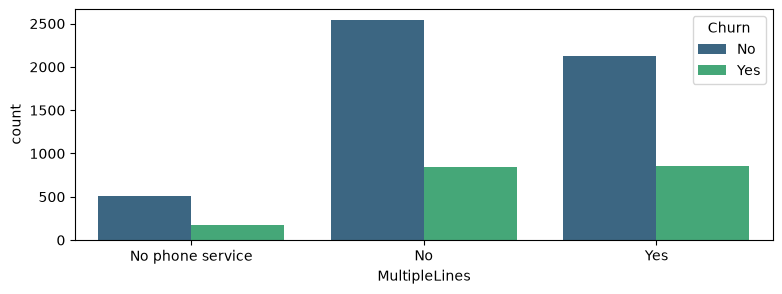

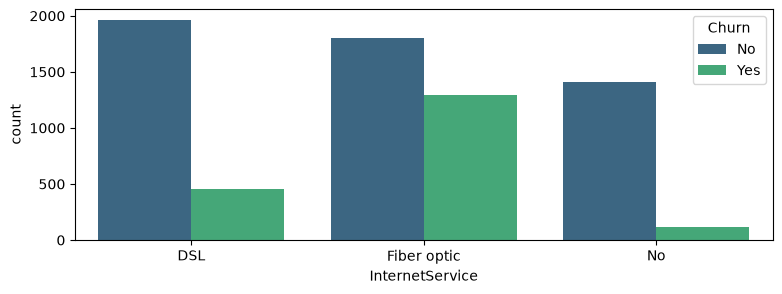

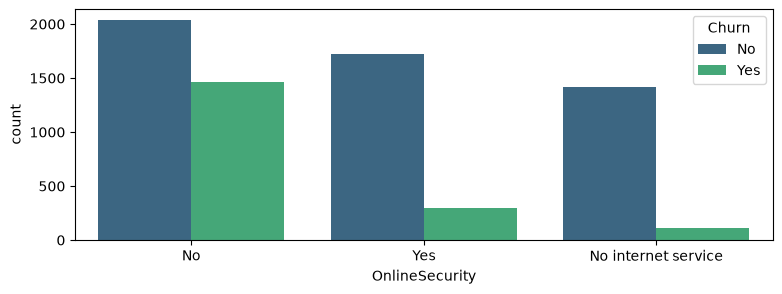

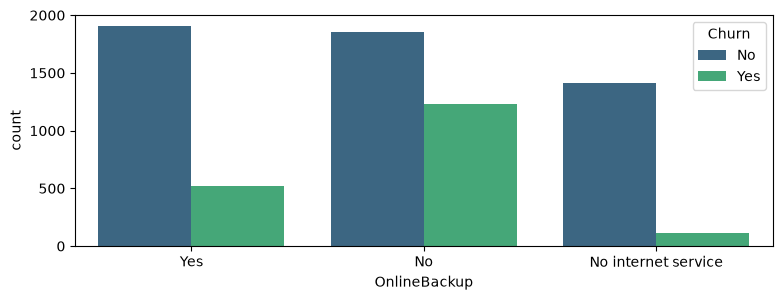

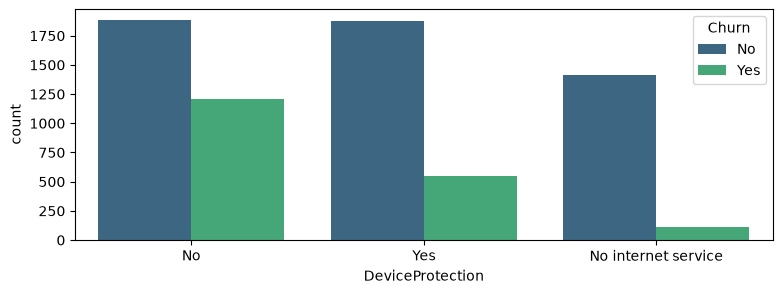

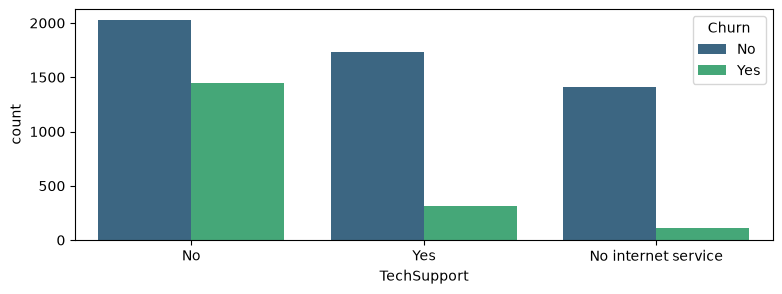

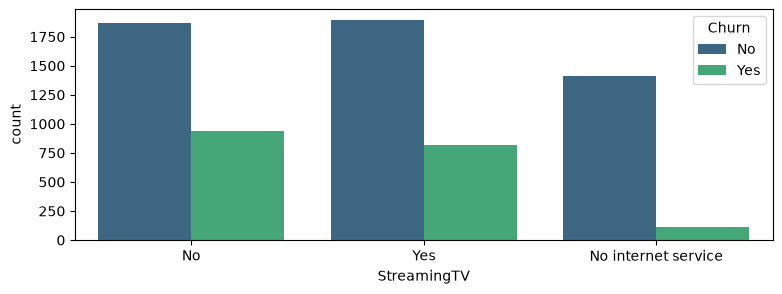

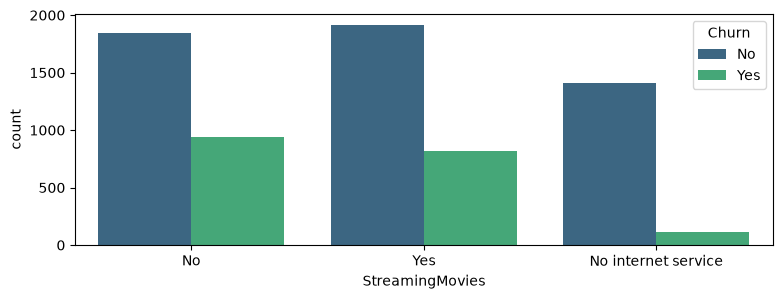

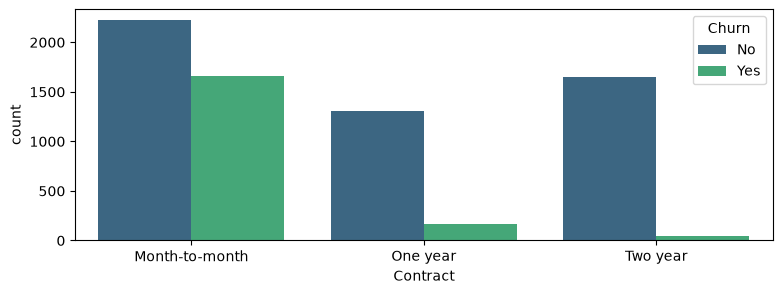

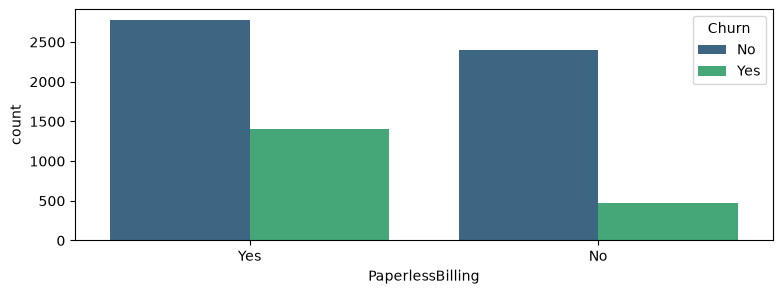

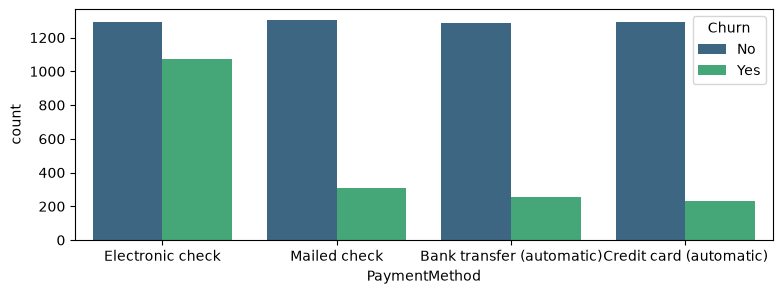

In [279]:
for col in cat_col:
    plt.figure(figsize=(9,3))
    sns.countplot(x=col, hue='Churn', palette='viridis', data= df)
    plt.show()

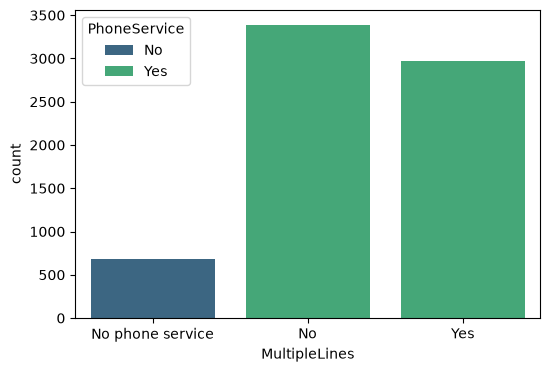

In [280]:
plt.figure(figsize=(6,4))
sns.countplot(x='MultipleLines',hue='PhoneService',data=df,palette='viridis')
plt.show()

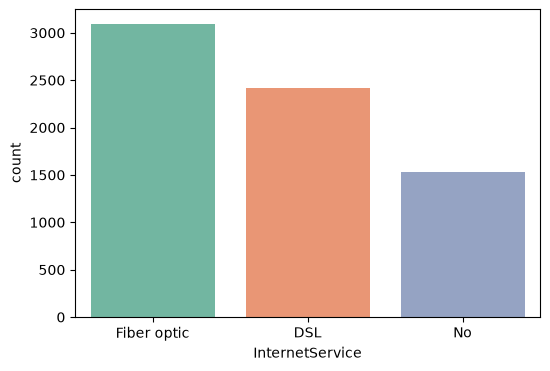

In [281]:
plt.figure(figsize=(6,4))
sns.barplot(x=df['InternetService'].value_counts().index,y=df['InternetService'].value_counts(),hue=df['InternetService'].value_counts().index,palette='Set2')
plt.show()

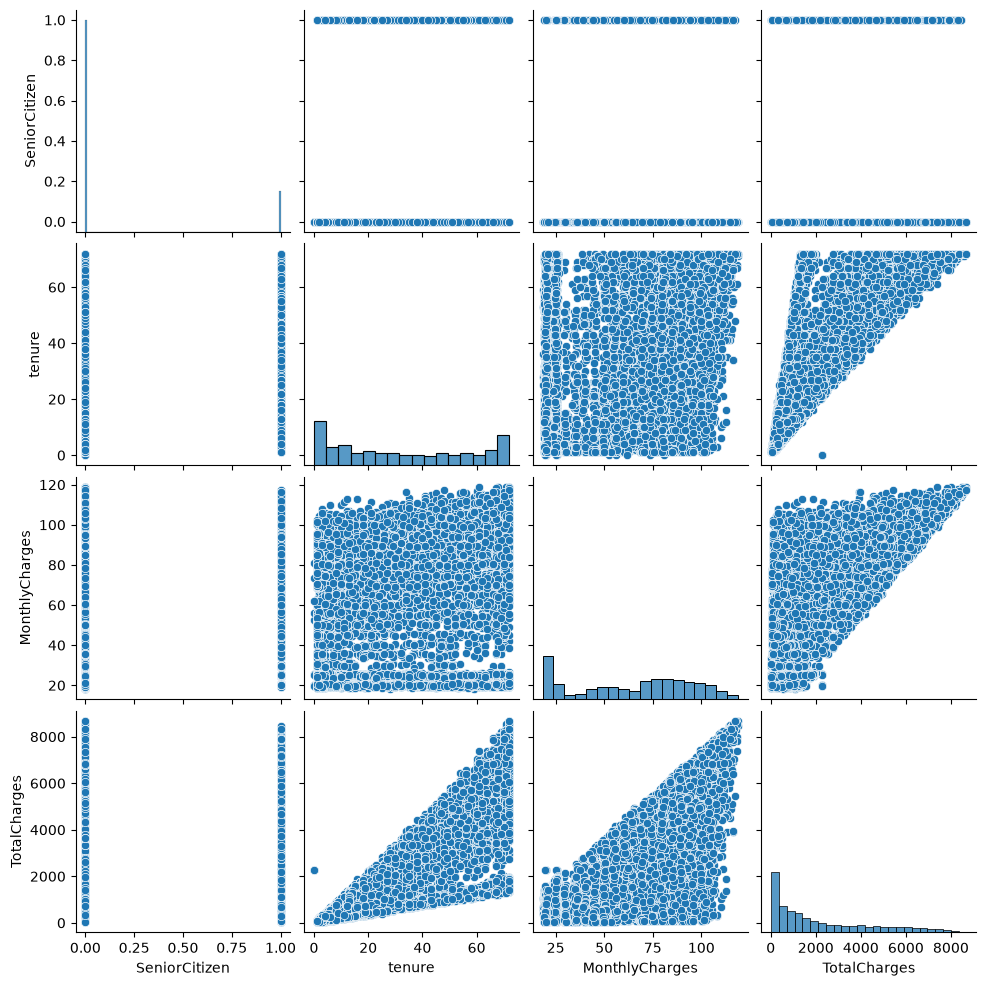

In [282]:
sns.pairplot(df)
plt.show()

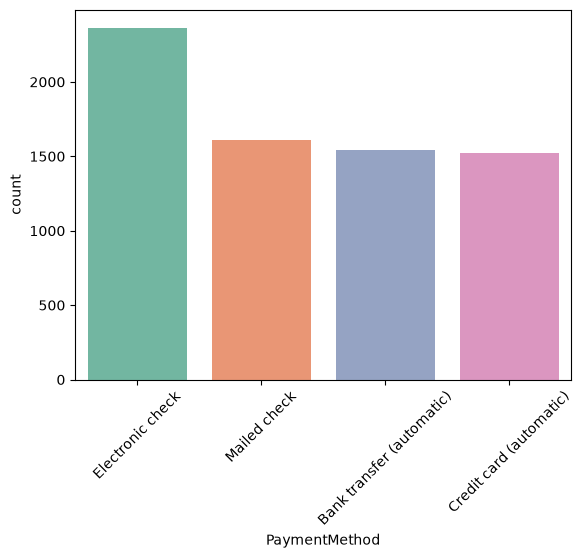

In [283]:
sns.barplot(x=df['PaymentMethod'].value_counts().index,y=df['PaymentMethod'].value_counts(),hue=df['PaymentMethod'].value_counts().index,palette='Set2')
plt.xticks(rotation=45)
plt.show()

In [284]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [285]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

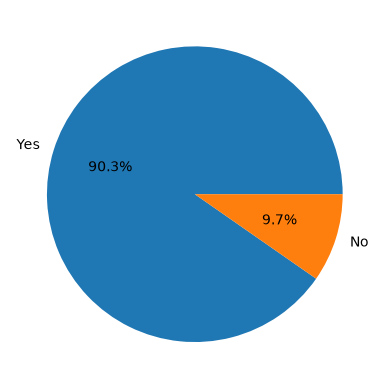

In [286]:
plt.pie(df['PhoneService'].value_counts(),labels=df['PhoneService'].value_counts().index,autopct='%1.1f%%')
plt.show()

<Axes: >

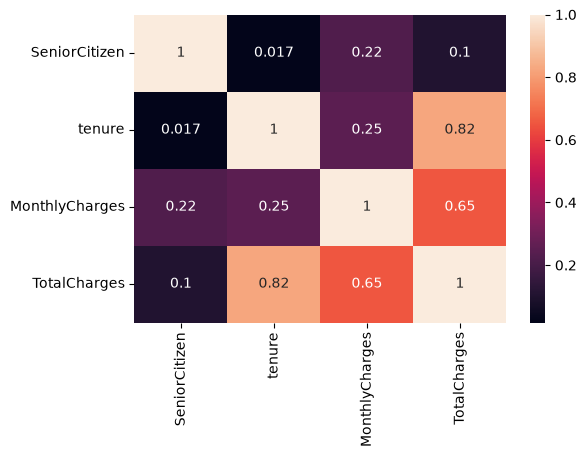

In [287]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

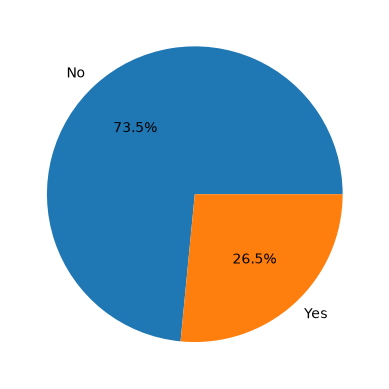

In [288]:
plt.pie(df['Churn'].value_counts(),labels=df['Churn'].value_counts().index,autopct='%1.1f%%')
plt.show()

In [289]:
df['tenure']=pd.qcut(df['tenure'],q=[0,0.25,0.75,1],labels=['short_term_customer','mid_term_customer','long_term_customer'])

In [290]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,short_term_customer,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,mid_term_customer,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,short_term_customer,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,mid_term_customer,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,short_term_customer,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,mid_term_customer,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,long_term_customer,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,mid_term_customer,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,short_term_customer,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


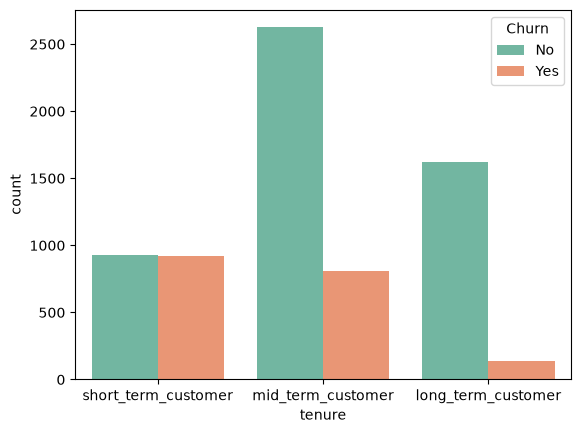

In [291]:
sns.countplot(x='tenure',hue='Churn',data=df,palette='Set2')
plt.show()

Encoding Data

In [292]:
df['gender']=df['gender'].map({'Male':0, 'Female':1})
df['gender'].value_counts()

gender
0    3555
1    3488
Name: count, dtype: int64

In [293]:
df['Partner']=df['Partner'].map({'No':0, 'Yes':1})
df['Partner'].value_counts()

Partner
0    3641
1    3402
Name: count, dtype: int64

In [294]:
cat_col.append('tenure')

In [295]:
cat_col[3:]

['Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'tenure']

In [296]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   int64   
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   int64   
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   category
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   s

In [297]:

enc=LabelEncoder()
for col in cat_col:
    df[col]=enc.fit_transform(df[col])

In [298]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,1,0,2,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,No
1,5575-GNVDE,0,0,0,0,1,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,No
2,3668-QPYBK,0,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,Yes
3,7795-CFOCW,0,0,0,0,1,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,No
4,9237-HQITU,1,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,Yes


In [299]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   int64  
 17  Paymen

Data Spliting

In [300]:
X=df.drop(columns=['customerID', 'Churn'])
y=df['Churn']

In [301]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,1,0,2,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,0,0,0,0,1,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,0,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,0,0,0,0,1,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,1,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,1,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,1,0,1,1,0,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,1,0,1,1,1,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,0,1,1,0,2,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60


In [302]:
y=y.map({'No': 0, 'Yes': 1})

In [303]:
scaler=StandardScaler()
X['MonthlyCharges']=scaler.fit_transform(X[['MonthlyCharges']])
X['TotalCharges'] =scaler.fit_transform(X[['TotalCharges']])

In [304]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [305]:
LR =LogisticRegression(max_iter=1000)

In [306]:
LR.fit(X_train,y_train)
y_pred = LR.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409

[[942  94]
 [168 205]]


In [307]:
DT = DecisionTreeClassifier()
KNN = KNeighborsClassifier()
XGB = XGBClassifier()
RFC = RandomForestClassifier()

Classifiers =[DT, KNN, XGB, RFC]

for Classifier in Classifiers:
    Classifier.fit(X_train, y_train)
    y_pred = Classifier.predict(X_test)

    print(f'By {Classifier} Classifier')
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test, y_pred))

By DecisionTreeClassifier() Classifier
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1036
           1       0.48      0.50      0.49       373

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409

[[837 199]
 [187 186]]
By KNeighborsClassifier() Classifier
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1036
           1       0.59      0.50      0.54       373

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

[[904 132]
 [185 188]]
By XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_

In [308]:
y_pred=best.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.53      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

[[930 106]
 [176 197]]


In [309]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr = LogisticRegression(max_iter=2000)

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Macro F1:", grid_lr.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': None, 'solver': 'liblinear'}
Best CV Macro F1: 0.7170775549127969


In [310]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409

[[940  96]
 [165 208]]


In [311]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV Macro F1:", grid_dt.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Macro F1: 0.7116785133988665


In [312]:
best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.51      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

[[935 101]
 [181 192]]


In [313]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_knn = GridSearchCV(
    knn,
    param_grid_knn,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best CV Macro F1:", grid_knn.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
Best CV Macro F1: 0.7131104495957971


In [314]:
best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1036
           1       0.63      0.56      0.59       373

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

[[911 125]
 [163 210]]


In [315]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Macro F1:", grid_xgb.best_score_)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Macro F1: 0.7265425923388065


In [316]:
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1036
           1       0.69      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

[[947  89]
 [177 196]]


In [317]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    random_state=42
)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Macro F1:", grid_rf.best_score_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Macro F1: 0.7301532901203789


In [318]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1036
           1       0.53      0.78      0.63       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

[[782 254]
 [ 83 290]]


In [319]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight=None,
    random_state=42
)

rf_final.fit(X_train, y_train)

y_pred_rf_final = rf_final.predict(X_test)

print(classification_report(y_test, y_pred_rf_final))
print(confusion_matrix(y_test, y_pred_rf_final))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

[[938  98]
 [177 196]]


In [320]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("Before:")
print(y_train.value_counts())

print("\nAfter RandomOverSampler:")
print(y_train_ros.value_counts())

Before:
Churn
0    4138
1    1496
Name: count, dtype: int64

After RandomOverSampler:
Churn
0    4138
1    4138
Name: count, dtype: int64


In [321]:
lr_ros = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_ros.fit(X_train_ros, y_train_ros)

y_pred_ros = lr_ros.predict(X_test)

print(classification_report(y_test, y_pred_ros))
print(confusion_matrix(y_test, y_pred_ros))

              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.83      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409

[[761 275]
 [ 65 308]]


In [322]:
from imblearn.pipeline import Pipeline

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_lr = Pipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('model', LogisticRegression(max_iter=2000))
])

param_grid_lr_ros = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

grid_lr_ros = GridSearchCV(
    pipeline_lr,
    param_grid_lr_ros,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr_ros.fit(X_train, y_train)

print("Best Parameters:")
print(grid_lr_ros.best_params_)

print("Best CV Macro F1:")
print(grid_lr_ros.best_score_)

Best Parameters:
{'model__C': 1, 'model__solver': 'lbfgs'}
Best CV Macro F1:
0.7149015068728792


In [323]:
best_lr_ros = grid_lr_ros.best_estimator_

y_pred_lr_ros = best_lr_ros.predict(X_test)

print(classification_report(y_test, y_pred_lr_ros))
print(confusion_matrix(y_test, y_pred_lr_ros))

              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.83      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409

[[761 275]
 [ 65 308]]


In [324]:
xgb_ros = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_ros.fit(X_train_ros, y_train_ros)

y_pred_xgb_ros = xgb_ros.predict(X_test)

print(classification_report(y_test, y_pred_xgb_ros))
print(confusion_matrix(y_test, y_pred_xgb_ros))

              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1036
           1       0.55      0.67      0.61       373

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409

[[833 203]
 [122 251]]


In [325]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_xgb_ros = Pipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

param_grid_xgb_ros = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

grid_xgb_ros = GridSearchCV(
    estimator=pipeline_xgb_ros,
    param_grid=param_grid_xgb_ros,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_xgb_ros.fit(X_train, y_train)

print("Best Parameters:")
print(grid_xgb_ros.best_params_)

print("\nBest CV Macro F1:")
print(grid_xgb_ros.best_score_)

Best Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.8}

Best CV Macro F1:
0.729375152719929


In [326]:
best_xgb_ros = grid_xgb_ros.best_estimator_

y_pred_xgb_ros = best_xgb_ros.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_ros))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_ros))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1036
           1       0.57      0.77      0.65       373

    accuracy                           0.78      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.78      0.79      1409

Confusion Matrix:
[[816 220]
 [ 86 287]]


In [327]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_xgb_ros = Pipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

param_grid_xgb_ros = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma': [0, 0.1, 0.3]
}

grid_xgb_ros = GridSearchCV(
    estimator=pipeline_xgb_ros,
    param_grid=param_grid_xgb_ros,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_xgb_ros.fit(X_train, y_train)

print("Best Parameters:")
print(grid_xgb_ros.best_params_)

print("\nBest CV Macro F1:")
print(grid_xgb_ros.best_score_)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best Parameters:
{'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__min_child_weight': 1, 'model__n_estimators': 100, 'model__subsample': 0.8}

Best CV Macro F1:
0.729375152719929


In [328]:
best_xgb_ros = grid_xgb_ros.best_estimator_

y_pred_xgb_ros = best_xgb_ros.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_ros))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_ros))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1036
           1       0.57      0.77      0.65       373

    accuracy                           0.78      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.78      0.79      1409


Confusion Matrix:
[[816 220]
 [ 86 287]]


In [329]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_rf_ros = Pipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('model', RandomForestClassifier(
        random_state=42
    ))
])

param_grid_rf_ros = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

grid_rf_ros = GridSearchCV(
    estimator=pipeline_rf_ros,
    param_grid=param_grid_rf_ros,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_rf_ros.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf_ros.best_params_)

print("\nBest CV Macro F1:")
print(grid_rf_ros.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Best CV Macro F1:
0.7320436804410679


In [330]:
best_rf_ros = grid_rf_ros.best_estimator_

y_pred_rf_ros = best_rf_ros.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_ros))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_ros))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.84      1036
           1       0.57      0.75      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409


Confusion Matrix:
[[826 210]
 [ 95 278]]


The experiments demonstrated different performance characteristics across models. Hyperparameter-tuned Logistic Regression achieved the highest overall accuracy (81%), whereas Logistic Regression combined with RandomOverSampler achieved the highest class-1 recall (83%). This indicates a trade-off between overall classification accuracy and minority-class detection.

ROS + Tuned XGBoost provided a balanced trade-off between overall classification performance and minority-class detection, achieving a macro F1-score of 0.75, class-1 recall of 0.77, and class-1 F1-score of 0.65.

Tuned Logistic Regression achieved the highest overall accuracy (81%), while ROS + Logistic Regression achieved the highest class-1 recall (83%). ROS + Tuned XGBoost provided an intermediate trade-off, with 78% accuracy, 77% class-1 recall, and 0.75 macro F1.